✅ Step 1: Load and Preprocess the MNIST Dataset

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

✅ Step 2: Define the CNN Architecture

In [10]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

c:\Users\DHRUV KUMAR\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Step 3: Compile the Model

In [11]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

✅ Step 4: Train the Model

In [12]:
history = model.fit(x_train, y_train, batch_size=128, epochs=15, validation_split=0.2)

Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.8339 - loss: 0.5498 - val_accuracy: 0.9812 - val_loss: 0.0644
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.9790 - loss: 0.0650 - val_accuracy: 0.9837 - val_loss: 0.0561
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.9869 - loss: 0.0395 - val_accuracy: 0.9862 - val_loss: 0.0475
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.9906 - loss: 0.0303 - val_accuracy: 0.9887 - val_loss: 0.0370
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.9919 - loss: 0.0240 - val_accuracy: 0.9907 - val_loss: 0.0359
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.9938 - loss: 0.0174 - val_accuracy: 0.9902 - val_loss: 0.0359
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - accuracy: 0.9963 - loss: 0.0117 - val_accuracy: 0.9898 - val_loss: 0.0407
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.9954 - loss: 0.0132 - v

✅ Step 5: Evaluate the Model

In [15]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9871 - loss: 0.0506
Test Accuracy: 0.9900
Test Loss: 0.0387


✅ Step 6: Visualize the Results

📈 Plot Training & Validation Accuracy/Loss

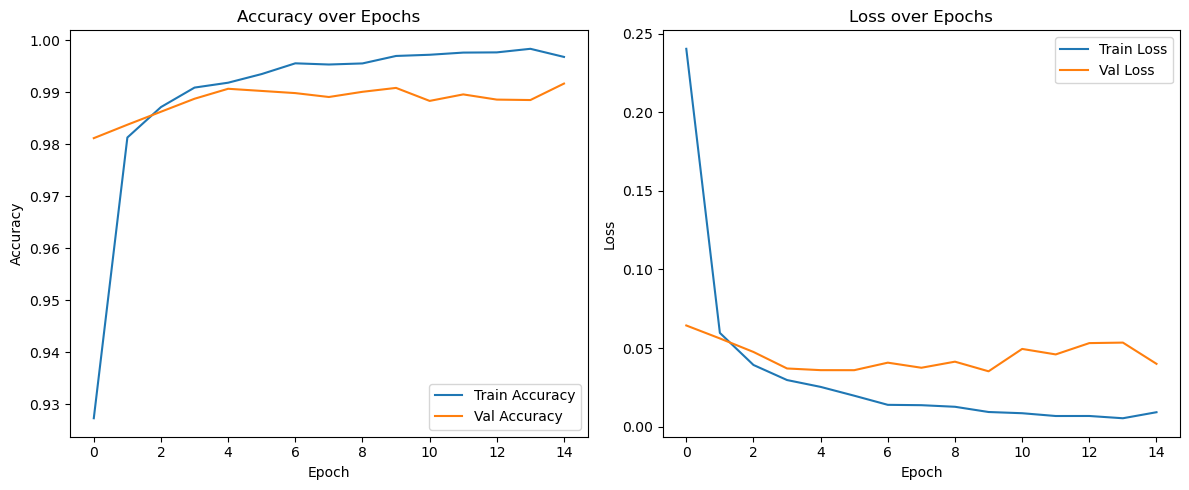

In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

🖼️ Display Predictions and Misclassifications

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


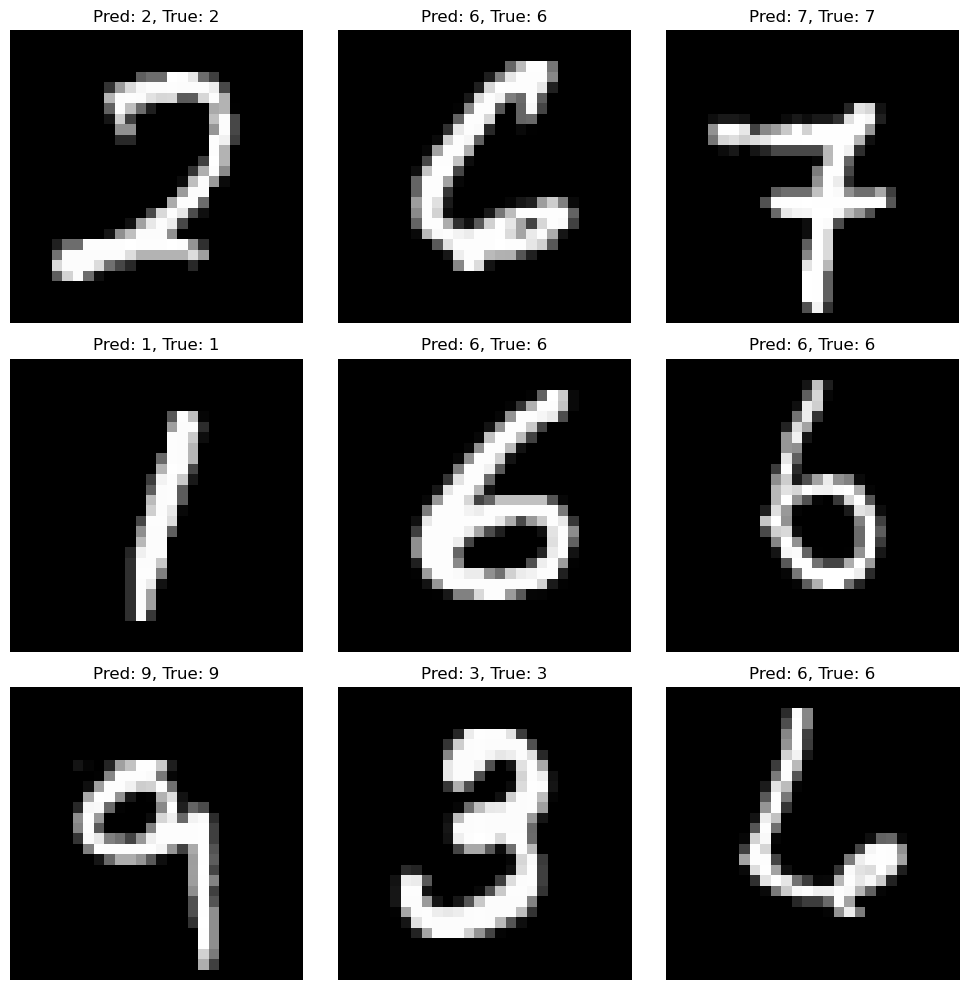

In [30]:
preds = model.predict(x_test)
pred_labels = np.argmax(preds, axis=1)
true_labels = np.argmax(y_test, axis=1)

plt.figure(figsize=(10, 10))
for i in range(9):
    idx = np.random.randint(0, len(x_test))
    plt.subplot(3, 3, i+1)
    plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {pred_labels[idx]}, True: {true_labels[idx]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

🧠 Visualize Filters (Optional Insight)

Filter shape: (3, 3, 1, 32)


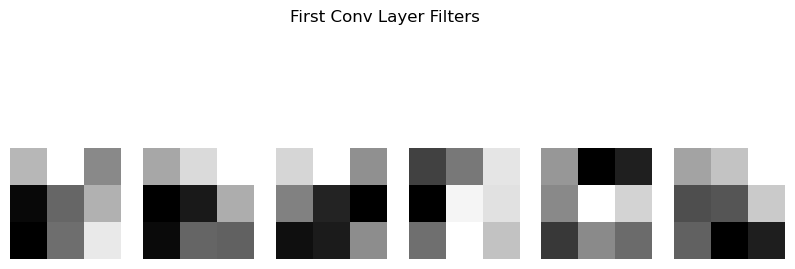

In [28]:
filters, biases = model.layers[0].get_weights()
print(f"Filter shape: {filters.shape}")

plt.figure(figsize=(10, 4))
for i in range(6):
    f = filters[:, :, 0, i]
    plt.subplot(1, 6, i+1)
    plt.imshow(f, cmap='gray')
    plt.axis('off')
plt.suptitle("First Conv Layer Filters")
plt.show()